In [1]:
import numpy as np
import torch
from torch import nn
from torch import optim 
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data.sampler import SequentialSampler, RandomSampler

In [2]:
import sys
sys.path.insert(1, '..')

from src.learning_models import *
import src.FastIF.fast_influence_utils.nn_influence_utils as influence_utils

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
from src.samplers import RandomSampler, InfluenceSampler as FastIFSampler

In [5]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features=1, out_features=5),
            nn.ReLU(),
            nn.Linear(in_features=5, out_features=25),
            nn.ReLU(),
            nn.Linear(in_features=25, out_features=75),
            nn.ReLU(),
            nn.Linear(in_features=75, out_features=200),
            nn.ReLU(),
            nn.Linear(in_features=200, out_features=100),
            nn.ReLU(),
            nn.Linear(in_features=100, out_features=50),
            nn.ReLU(),
            nn.Linear(in_features=50, out_features=25),
            nn.ReLU(),
            nn.Linear(in_features=25, out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10, out_features=1),
        )

    def forward(self, x):
        logits = self.net(x)
        return logits

## Dataset

In [6]:
def create_dataset(n_features, clear_data_size, noisy_data_size, noise_amplitude=1, train_ratio=.6, eval_ratio=.2, test_ratio=.2, seed=235567):
    torch.manual_seed(seed)
    
    X_clear = -10 + 20 * torch.rand(clear_data_size, 1, n_features)
    X_noisy = -10 + 20 * torch.rand(noisy_data_size, 1, n_features)

    lr_coefs = -1 + 2 * torch.rand(N_FEATURES)

    y_clear = sum(lr_coefs[k] * X_clear[:, :, k] for k in range(n_features)).reshape([clear_data_size, 1, 1])
    y_noisy = sum(lr_coefs[k] * X_noisy[:, :, k] for k in range(N_FEATURES)).reshape([noisy_data_size, 1, 1]) + \
                noise_amplitude * lr_coefs.mean() * torch.randn(noisy_data_size, 1, 1)

    X_train, X_eval, X_test = torch.split(X_clear, tuple(
        map(int, [clear_data_size * train_ratio, clear_data_size * eval_ratio, clear_data_size * test_ratio])
    ))
    y_train, y_eval, y_test = torch.split(y_clear, tuple(
        map(int, [clear_data_size * train_ratio, clear_data_size * eval_ratio, clear_data_size * test_ratio])
    ))

    X_train = torch.cat([X_train, X_noisy])
    y_train = torch.cat([y_train, y_noisy])

    train_size = int(clear_data_size * train_ratio) + noisy_data_size

    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))
    ax1.scatter(X_clear.reshape([clear_data_size]), y_clear.reshape([clear_data_size]))
    ax1.set_title("all data without noise")
    
    ax2.scatter(X_train.reshape([train_size]), y_train.reshape([train_size]))
    ax2.set_title("train with noise")
    
    plt.show()

    return (X_train, y_train), (X_eval, y_eval), (X_test, y_test)

In [7]:
def run_experiment(noisy_data_size, calculate_inlf_func_ratio, sampler_k_values):
    res = {}

    (X_train, y_train), (X_eval, y_eval), (X_test, y_test) = create_dataset(n_features=N_FEATURES,
                                                                            clear_data_size=DS_SIZE,
                                                                            noisy_data_size=noisy_data_size,
                                                                            noise_amplitude=NOISE_AMPLITUDE,
                                                                            train_ratio=TRAIN_RATIO,
                                                                            eval_ratio=EVAL_RATIO,
                                                                            test_ratio=TEST_RATIO,
                                                                           )
    res["(X,y)_train"] = (X_train, y_train)
    res["loss"] = {}
    
    torch.manual_seed(123)
    nn_model1 = Net()
    train_dataloader = get_dataloader(X_train, y_train, batch_size=BATCH_SIZE, random=True)

    res["loss"]["all_data"] = train_nn(nn_model1, train_dataloader, X_eval, y_eval, EPOCHS, LR)
    show_graphics_loss(res["loss"]["all_data"])

    influences = influence_utils.run_full_influence_functions(
        nn_model1,
        get_dataloader(X_train, y_train, batch_size=BATCH_SIZE, random= True),
        get_dataloader(X_train, y_train, batch_size=         1, random=False),
        get_dataloader( X_eval,  y_eval, batch_size=         1, random=False),
        num_examples_to_test=int(DS_SIZE * EVAL_RATIO * calculate_inlf_func_ratio),
        s_test_num_samples=100
    )
    inf_test_all_sum = {}
    inf_test_all_max = {}
    inf_test_all_min = {}
    for i in range(int(DS_SIZE * EVAL_RATIO * calculate_inlf_func_ratio)):
        for k in range(X_train.shape[0]):
            inf_test_all_sum[k] = inf_test_all_sum.get(k, 0) + influences[i]["influences"][k]
            inf_test_all_max[k] = max(inf_test_all_max.get(k, 0), influences[i]["influences"][k])
            inf_test_all_min[k] = min(inf_test_all_max.get(k, 0), influences[i]["influences"][k])

    show_graphics_influence(X_train, y_train, inf_test_all_sum, inf_test_all_max, inf_test_all_min)
    res["influences"] = influences

    for sampler_k_value in sampler_k_values:
        k = int(X_train.shape[0] * sampler_k_value)
        temp = {}
        rnd_sampler = RandomSampler(k)
        fastif_sampler = FastIFSampler(k)
    
        temp["rnd"]         = run_sampler(rnd_sampler,    X_train, y_train, X_eval, y_eval, times_to_run_sampler=20)
        temp["fastif_mean"] = run_sampler(fastif_sampler, X_train, y_train, X_eval, y_eval, influences=inf_test_all_sum)
        temp["fastif_max"]  = run_sampler(fastif_sampler, X_train, y_train, X_eval, y_eval, influences=inf_test_all_max)
        temp["fastif_min"]  = run_sampler(fastif_sampler, X_train, y_train, X_eval, y_eval, influences=inf_test_all_min)
        
        res["loss"][f"top{sampler_k_value*100}%"] = temp

    return res

In [8]:
def run_sampler(sampler, X_train, y_train, X_eval, y_eval, times_to_run_sampler=1, influences=None):
    if isinstance(sampler, FastIFSampler) and influences is None:
        raise ValueError

    loss_hists = []
    for _ in range(times_to_run_sampler):
        sampler_X_train, sampler_y_train, *_ = sampler(X_train, y_train, torch.ones(*y_train.shape), influences=influences)

        torch.manual_seed(123)
        nn_model = Net()
        train_dataloader = get_dataloader(sampler_X_train, sampler_y_train, batch_size=BATCH_SIZE, random=True)
        
        loss_hists.append(train_nn(nn_model, train_dataloader, X_eval, y_eval, EPOCHS, LR))

    return np.array(loss_hists).mean(axis=0)

In [9]:
def show_graphics_loss(hist):
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))
    ax1.plot(hist[0])
    ax1.set_title("loss function")
    ax1.set_xlabel("EPOCH")
    
    ax2.plot(hist[1])
    ax2.set_title("MSE validation loss")
    ax2.set_xlabel("EPOCH")
    
    plt.show()

In [10]:
def show_graphics_influence(X_train, y_train, inf_test_all_sum, inf_test_all_max, inf_test_all_min):
    _, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 7))
    fig1 = ax1.scatter(X_train.reshape([-1]), y_train.reshape([-1]), c=inf_test_all_sum.values())
    ax1.set_title("$\\sum_{i=1}^{N}\\; \\mathcal{I}(z, z_{test}^i)$")
    
    fig2 = ax2.scatter(X_train.reshape([-1]), y_train.reshape([-1]), c=inf_test_all_max.values())
    ax2.set_title("$\\max_{i}\\; \\mathcal{I}(z, z_{test}^i)$")
    
    fig3 = ax3.scatter(X_train.reshape([-1]), y_train.reshape([-1]), c=inf_test_all_min.values())
    ax3.set_title("$\\min_{i}\\; \\mathcal{I}(z, z_{test}^i)$")
    
    plt.colorbar(fig1, ax=ax1)
    plt.colorbar(fig2, ax=ax2)
    plt.colorbar(fig3, ax=ax3)
    plt.show()

In [11]:
def show_samplers_loss_graphics(hist, key2):
    f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))

    ax1.plot(hist["all_data"][0], label="all")
    ax1.plot(hist[key2]["rnd"][0], label="random")
    ax1.plot(hist[key2]["fastif_mean"][0], label="fastif mean")
    ax1.plot(hist[key2]["fastif_max"][0], label="fastif max")
    ax1.plot(hist[key2]["fastif_min"][0], label="fastif min")
    ax1.legend()
    ax1.set_title("running training loss")
    
    ax2.plot(hist["all_data"][1], label="all")
    ax2.plot(hist[key2]["rnd"][1], label="random")
    ax2.plot(hist[key2]["fastif_mean"][1], label="fastif mean")
    ax2.plot(hist[key2]["fastif_max"][1], label="fastif max")
    ax2.plot(hist[key2]["fastif_min"][1], label="fastif min")
    ax2.legend()
    ax2.set_title("validation MSE loss")
    plt.show()

In [12]:
N_FEATURES = 1
DS_SIZE = 1000
TRAIN_RATIO, EVAL_RATIO, TEST_RATIO = .6, .4, .0
NOISE_AMPLITUDE = 2

In [13]:
BATCH_SIZE = 4
EPOCHS = 15
LR = 0.01

In [14]:
results = {}

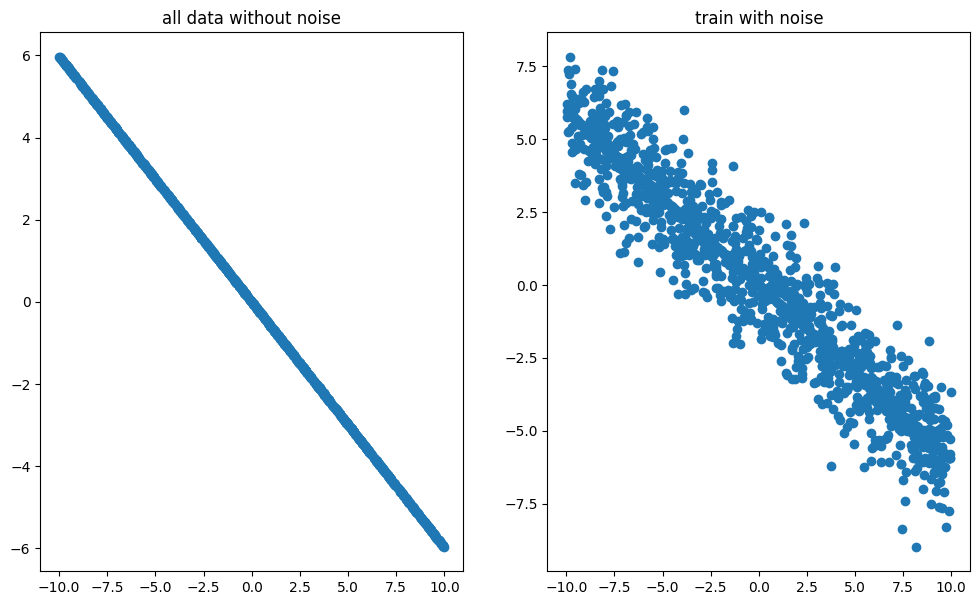

Epoch: 15, Batch: 399, Loss: 459.07: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6000/6000 [00:19<00:00, 314.77it/s]


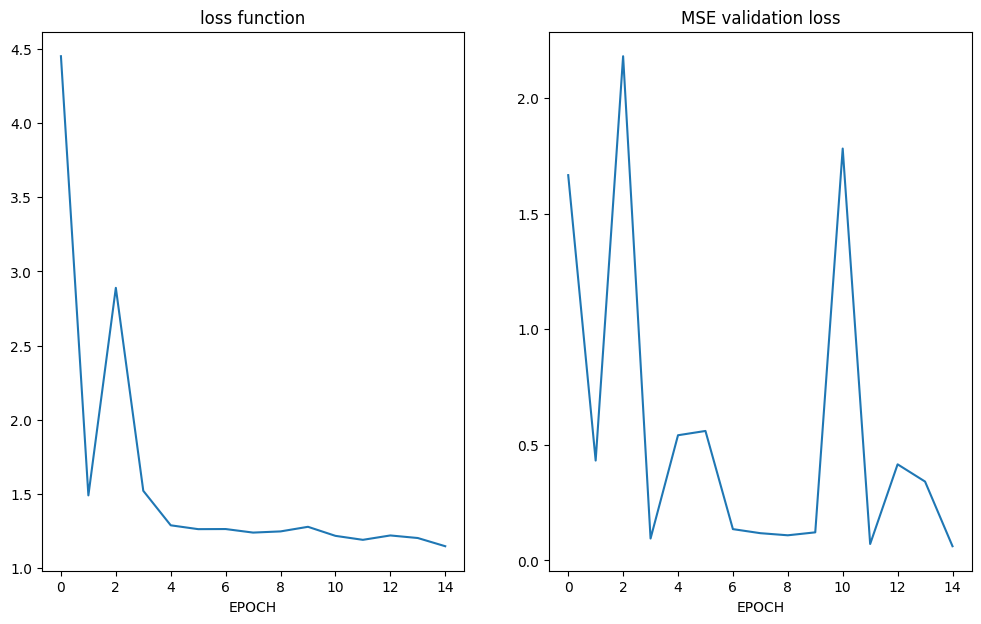

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [02:00<00:00,  3.02s/it]


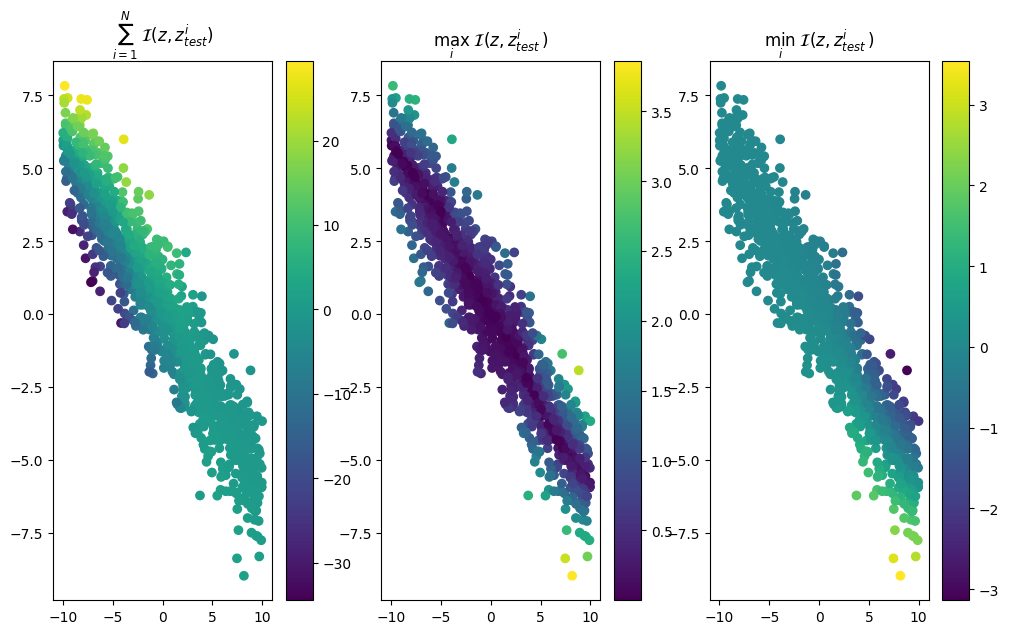

Epoch: 15, Batch: 199, Loss: 134.18: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:11<00:00, 256.79it/s]


In [17]:
results["1000 noise, .1 calculte IF ratio"] = run_experiment(1000, .1, [.1, .2, .5])

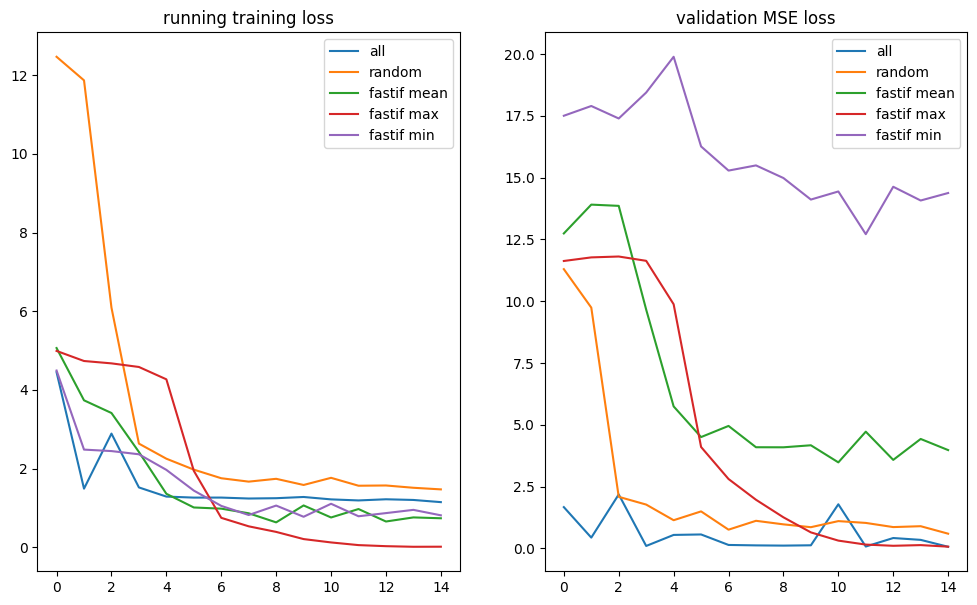

In [21]:
show_samplers_loss_graphics(results["1000 noise, .1 calculte IF ratio"]["loss"], "top10.0%")

In [22]:
import pickle


with open('res.pkl', 'wb') as f:
    pickle.dump(results, f)